# Knapsack Benchmark — Analysis & Visualizations

Notebook phân tích kết quả benchmark sau khi chạy các thuật toán.
Biểu đồ được lưu tự động vào `results/plots/` (300 DPI).

**Sections:**
1. Setup & Load CSV
2. Runtime vs N (log scale + curve fit)
3. Grouped bar: mean runtime per algorithm
4. Memory profiling (stress)
5. Pearson r vs Branch & Bound runtime
6. Heatmap: runtime by (n, algorithm)
7. Knapsack hierarchy (Fractional / Unbounded / 0-1)

In [1]:
from __future__ import annotations
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

try:
    from scipy.optimize import curve_fit
except ImportError:
    curve_fit = None

# ── Design system ────────────────────────────────────────────────────────────
FIG_BG    = "#0f0f1a"
AX_BG     = "#16213e"
GRID_CLR  = "#2a2a4a"
TEXT_CLR  = "#dde1f0"
MUTED_CLR = "#8890b0"
PALETTE   = ["#7b68ee", "#00d4aa", "#ff6b6b", "#ffd166", "#06d6a0",
             "#ef476f", "#118ab2", "#fca311", "#e9c46a"]

plt.rcParams.update({
    "figure.facecolor": FIG_BG,
    "axes.facecolor":   AX_BG,
    "axes.edgecolor":   GRID_CLR,
    "axes.labelcolor":  MUTED_CLR,
    "axes.grid":        True,
    "grid.color":       GRID_CLR,
    "grid.linewidth":   0.5,
    "grid.linestyle":   "--",
    "text.color":       TEXT_CLR,
    "xtick.color":      MUTED_CLR,
    "ytick.color":      MUTED_CLR,
    "legend.framealpha": 0.85,
    "legend.edgecolor": GRID_CLR,
    "legend.facecolor": AX_BG,
    "legend.labelcolor": TEXT_CLR,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

def style_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title, color=TEXT_CLR, pad=8)
    ax.set_xlabel(xlabel, color=MUTED_CLR)
    ax.set_ylabel(ylabel, color=MUTED_CLR)
    ax.set_axisbelow(True)

def algo_palette(algos):
    return {a: PALETTE[i % len(PALETTE)] for i, a in enumerate(sorted(algos))}

def resolve_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, cwd.parent]:
        if (p / "results").exists():
            return p
    return cwd

ROOT   = resolve_root()
PLOTS  = ROOT / "results" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    fig.savefig(PLOTS / name, dpi=300, bbox_inches="tight", facecolor=FIG_BG)
    print(f"Saved -> {PLOTS / name}")

print("Root:", ROOT)

Root: E:\Antigravity Workspace\Knapsack\KnapsackOptimization


## 1 · Load & Preprocess CSV

In [2]:
CSV_PATH = ROOT / "results" / "csv" / "benchmark_results_timeout5.csv"
if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

# Numeric coercion
for col in ["time_sec", "peak_memory_mb", "optimal_value",
            "n", "capacity", "pearson_corr", "density_variance"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

TIMEOUT_SEC = int(os.getenv("BENCHMARK_TIMEOUT_SEC", "60"))
df["is_timeout"] = df["status"].str.upper().eq("TIMEOUT")
df["is_oom"]     = df["status"].str.upper().eq("OOM")
df["is_success"] = df["status"].str.upper().eq("SUCCESS")

# Capped timeout time for plotting
df["time_plot"] = df["time_sec"].copy()
df.loc[df["is_timeout"], "time_plot"] = TIMEOUT_SEC

# OOM memory → NaN (don't plot)
df.loc[df["is_timeout"] | df["status"].str.upper().eq("ERROR"), "peak_memory_mb"] = np.nan

ALGOS   = sorted(df["algorithm"].unique())
PAL     = algo_palette(ALGOS)

print(f"Rows: {len(df)} | Algorithms: {len(ALGOS)} | "
      f"Timeouts: {df['is_timeout'].sum()} | OOM: {df['is_oom'].sum()}")
display(df[["algorithm","n","time_sec","peak_memory_mb","status"]].head(10))

Rows: 1920 | Algorithms: 10 | Timeouts: 743 | OOM: 0


,algorithm,n,time_sec,peak_memory_mb,status
0,DP,100,0.27971,6.1972,SUCCESS
1,BranchAndBound,100,0.00063,0.0063,SUCCESS
2,Backtracking,100,5.00000,NaN,TIMEOUT
3,GomoryCut,100,5.00000,NaN,TIMEOUT
4,SimplexBnB,100,5.00000,NaN,TIMEOUT
5,GreedyFractional,100,0.00018,0.0049,SUCCESS
6,PrimalSimplex,100,5.00000,NaN,TIMEOUT
7,DualSimplex,100,5.00000,NaN,TIMEOUT
8,Greedy01,100,0.00017,0.0038,SUCCESS
9,DPUnbounded,100,0.15791,0.1622,SUCCESS


## 2 · Runtime vs N (log scale + curve fit)

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\runtime_vs_n.png


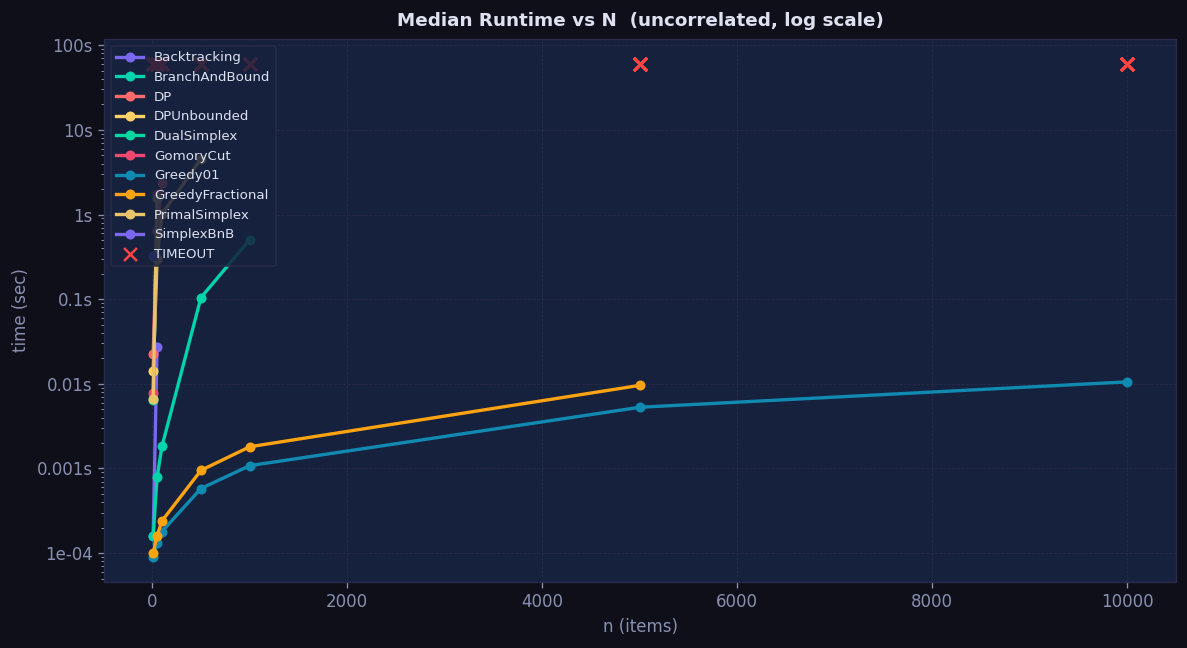

In [3]:
df_ok = df[df["is_success"] & df["time_sec"].gt(0)].copy()

# Near-uncorrelated subset for fair comparison
if "pearson_corr" in df_ok.columns:
    df_ok = df_ok[df_ok["pearson_corr"].abs() <= 0.15]

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor=FIG_BG)

for algo in ALGOS:
    sub = df_ok[df_ok["algorithm"] == algo].sort_values("n")
    if sub.empty:
        continue
    grp = sub.groupby("n")["time_sec"].median().reset_index()
    ax.plot(grp["n"], grp["time_sec"], "o-",
            color=PAL[algo], lw=2, ms=5, label=algo, zorder=3)

# Mark timeouts
timeout_sub = df[df["is_timeout"]]
if not timeout_sub.empty:
    ax.scatter(timeout_sub["n"], timeout_sub["time_plot"],
               marker="x", s=60, color="#ff4444", lw=1.5,
               label="TIMEOUT", zorder=5)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x:.0e}" if x < 0.001 else f"{x:.3g}s"
))
ax.legend(loc="upper left", fontsize=8)
style_ax(ax, "Median Runtime vs N  (uncorrelated, log scale)", "n (items)", "time (sec)")
fig.tight_layout()
save(fig, "runtime_vs_n.png")
plt.show()

## 3 · Mean Runtime per Algorithm (grouped by N)

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\mean_runtime_bar.png


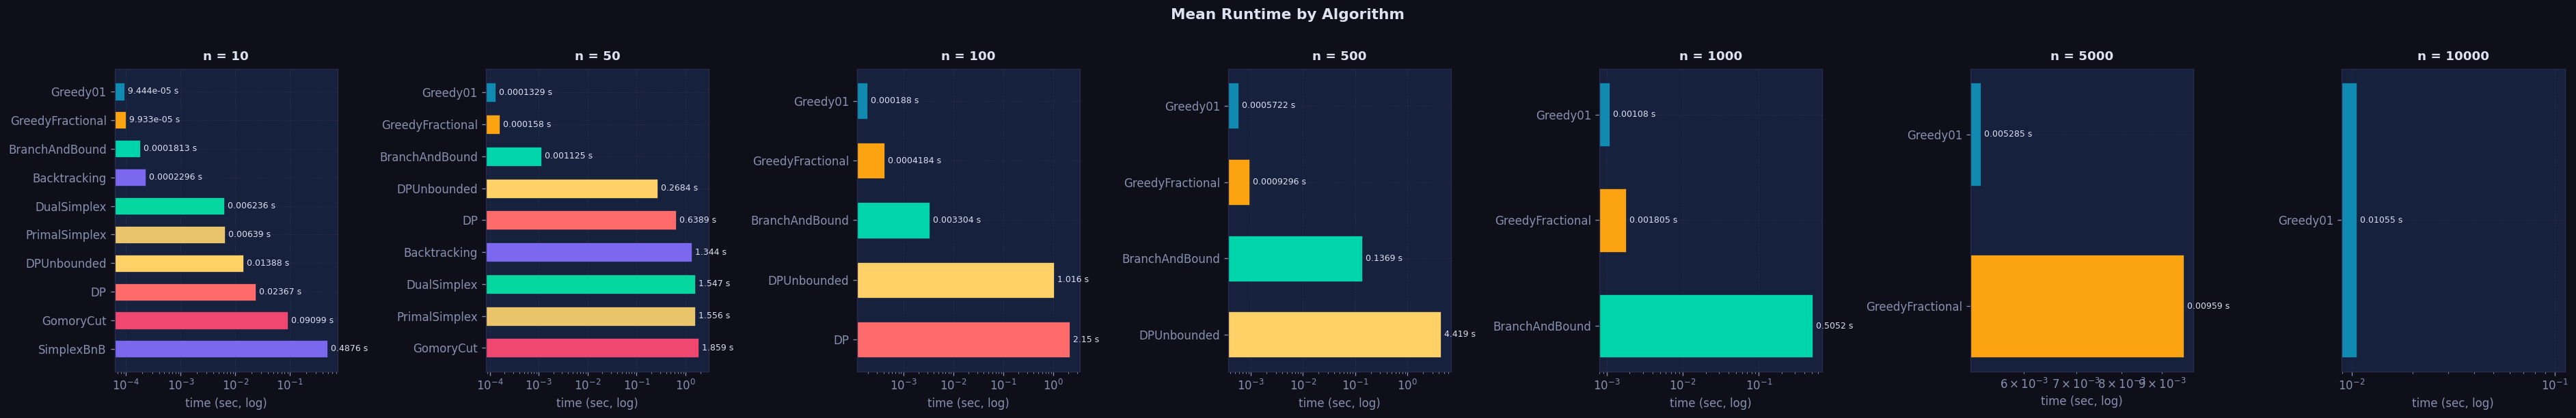

In [4]:
grp = (df[df["is_success"]]
       .groupby(["algorithm", "n"])["time_sec"]
       .mean()
       .reset_index()
       .rename(columns={"time_sec": "mean_time"}))

n_vals = sorted(grp["n"].unique())
fig, axes = plt.subplots(1, len(n_vals), figsize=(4.5 * len(n_vals), 5),
                          sharey=False, facecolor=FIG_BG)
if len(n_vals) == 1:
    axes = [axes]

for ax, nv in zip(axes, n_vals):
    sub = grp[grp["n"] == nv].sort_values("mean_time", ascending=True)
    colors = [PAL[a] for a in sub["algorithm"]]
    bars = ax.barh(sub["algorithm"], sub["mean_time"], color=colors,
                   edgecolor=AX_BG, linewidth=0.4, height=0.6)
    ax.bar_label(bars, fmt="%.4g s", padding=3,
                 color=TEXT_CLR, fontsize=7.5)
    ax.set_xscale("log")
    style_ax(ax, f"n = {nv}", "time (sec, log)")
    ax.invert_yaxis()

fig.suptitle("Mean Runtime by Algorithm", color=TEXT_CLR,
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
save(fig, "mean_runtime_bar.png")
plt.show()

## 4 · Memory Profiling

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\memory_vs_n.png


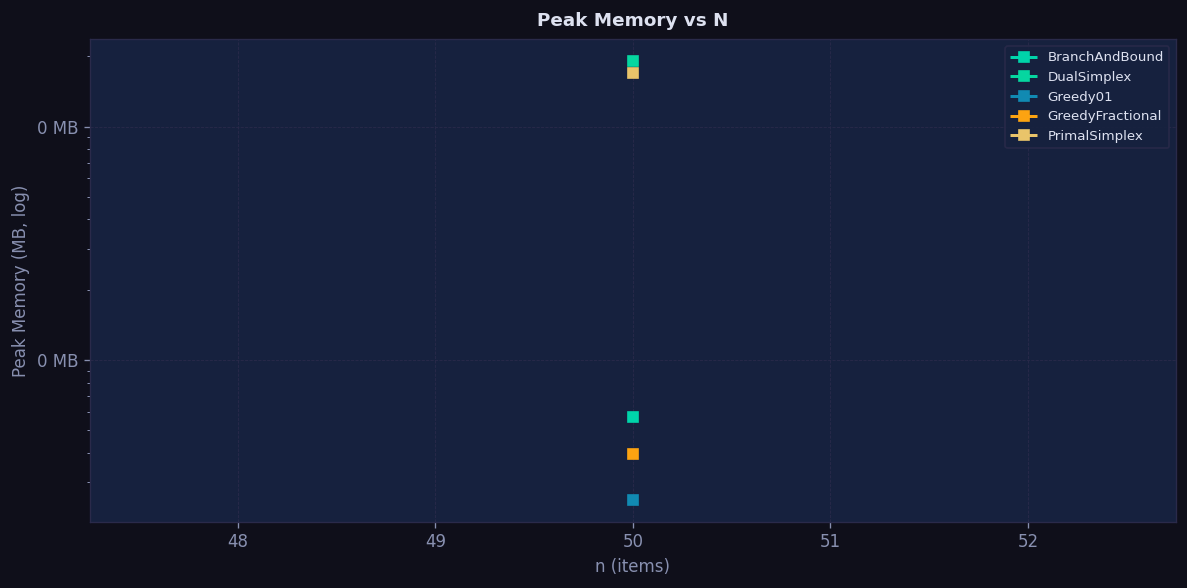

In [5]:
df_mem = df[df["peak_memory_mb"].notna()].copy()

if df_mem.empty:
    print("No memory data.")
else:
    # Prefer stress scenario
    stress = df_mem[df_mem["test_id"].astype(str).str.contains("stress", case=False)]
    df_plot = stress if not stress.empty else df_mem

    grp_mem = (df_plot
               .groupby(["algorithm", "n"])["peak_memory_mb"]
               .mean()
               .reset_index())

    fig, ax = plt.subplots(figsize=(10, 5), facecolor=FIG_BG)
    for algo in ALGOS:
        sub = grp_mem[grp_mem["algorithm"] == algo].sort_values("n")
        if sub.empty:
            continue
        ax.plot(sub["n"], sub["peak_memory_mb"], "s--",
                color=PAL[algo], lw=1.8, ms=6, label=algo)

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x:.0f} MB"
    ))
    ax.legend(fontsize=8)
    style_ax(ax, "Peak Memory vs N", "n (items)", "Peak Memory (MB, log)")
    fig.tight_layout()
    save(fig, "memory_vs_n.png")
    plt.show()

## 5 · Pearson r vs Branch & Bound Runtime

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\bnb_pearson_runtime.png


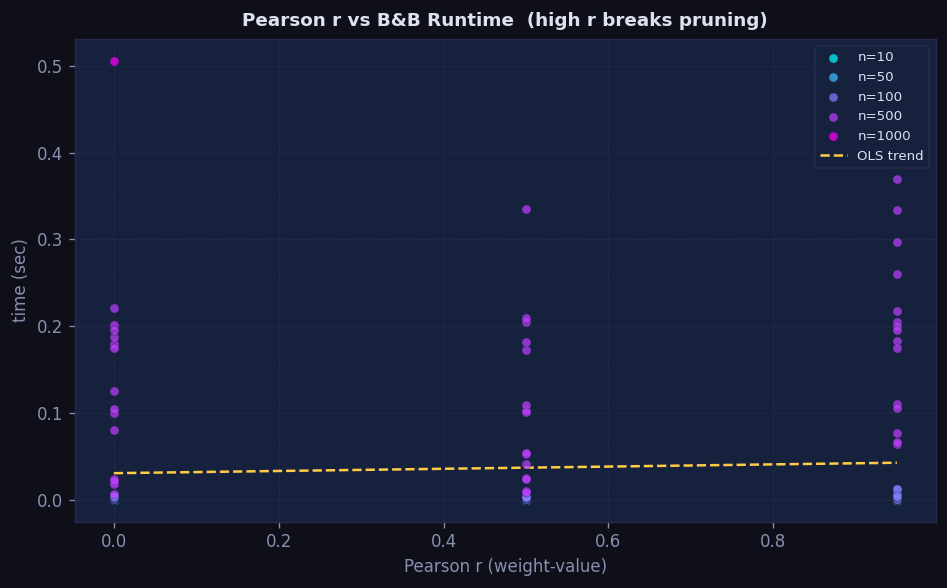

In [6]:
bnb_mask = df["algorithm"].str.contains("BranchAndBound|Branch.*Bound", na=False, case=False)
bnb = df[bnb_mask & df["status"].str.upper().isin(["SUCCESS","TIMEOUT"])].copy()

if bnb.empty:
    print("No B&B data found.")
else:
    n_vals_bnb = sorted(bnb["n"].unique())
    cmap = plt.colormaps["cool"].resampled(len(n_vals_bnb))

    fig, ax = plt.subplots(figsize=(8, 5), facecolor=FIG_BG)
    for i, nv in enumerate(n_vals_bnb):
        sub = bnb[bnb["n"] == nv]
        ax.scatter(sub["pearson_corr"], sub["time_plot"],
                   color=cmap(i), s=30, alpha=0.7,
                   linewidths=0.3, edgecolors=AX_BG, label=f"n={nv}", zorder=3)

    # OLS line across all n
    sub_ok = bnb[bnb["is_success"] & bnb["pearson_corr"].notna()]
    if len(sub_ok) >= 3:
        m, b = np.polyfit(sub_ok["pearson_corr"], sub_ok["time_plot"], 1)
        xs = np.linspace(sub_ok["pearson_corr"].min(), sub_ok["pearson_corr"].max(), 100)
        ax.plot(xs, m*xs+b, "--", color="#ffcc44", lw=1.5, label="OLS trend")

    ax.legend(fontsize=8)
    style_ax(ax, "Pearson r vs B&B Runtime  (high r breaks pruning)",
             "Pearson r (weight-value)", "time (sec)")
    fig.tight_layout()
    save(fig, "bnb_pearson_runtime.png")
    plt.show()

## 6 · Runtime Heatmap (Algorithm × N)

C:\Users\admin\AppData\Local\Temp\ipykernel_17916\2073518492.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  cmap="plasma", annot=pivot.applymap(lambda x: f"{x:.3g}"),


Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\runtime_heatmap.png


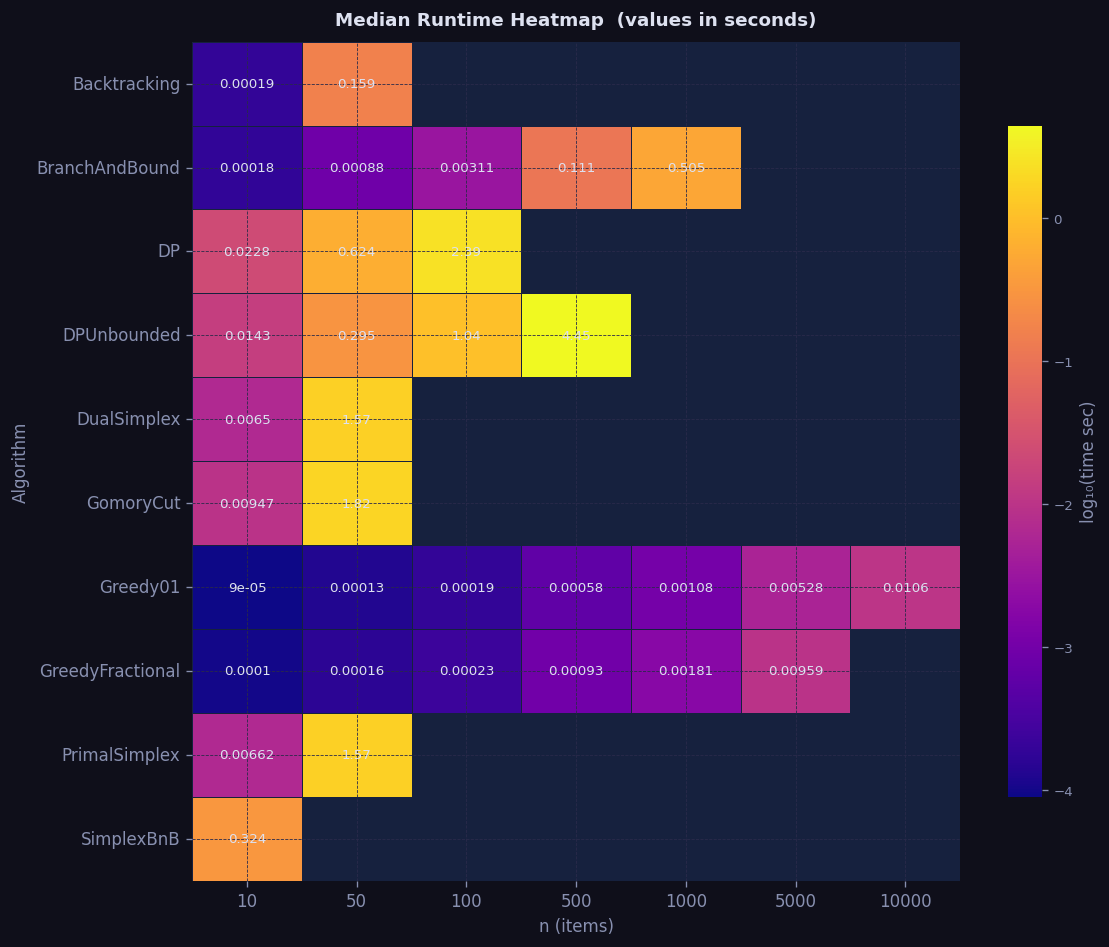

In [7]:
pivot = (df[df["is_success"]]
         .groupby(["algorithm", "n"])["time_sec"]
         .median()
         .unstack("n"))

if pivot.empty:
    print("Not enough data for heatmap.")
else:
    fig, ax = plt.subplots(figsize=(max(6, len(pivot.columns)*1.4),
                                    max(4, len(pivot)*0.8)),
                            facecolor=FIG_BG)
    log_pivot = np.log10(pivot.replace(0, np.nan))

    im = sns.heatmap(
        log_pivot, ax=ax,
        cmap="plasma", annot=pivot.applymap(lambda x: f"{x:.3g}"),
        fmt="", annot_kws={"size": 8, "color": TEXT_CLR},
        linewidths=0.4, linecolor=AX_BG,
        cbar_kws={"label": "log₁₀(time sec)", "shrink": 0.8},
    )
    ax.set_xlabel("n (items)", color=MUTED_CLR)
    ax.set_ylabel("Algorithm", color=MUTED_CLR)
    ax.set_title("Median Runtime Heatmap  (values in seconds)",
                 color=TEXT_CLR, pad=10, fontweight="bold")
    ax.tick_params(colors=MUTED_CLR)
    im.collections[0].colorbar.ax.tick_params(colors=MUTED_CLR, labelsize=8)
    im.collections[0].colorbar.ax.yaxis.label.set_color(MUTED_CLR)
    fig.tight_layout()
    save(fig, "runtime_heatmap.png")
    plt.show()

## 7 · Knapsack Hierarchy (Fractional / Unbounded / 0-1)

Saved -> E:\Antigravity Workspace\Knapsack\KnapsackOptimization\results\plots\knapsack_hierarchy.png


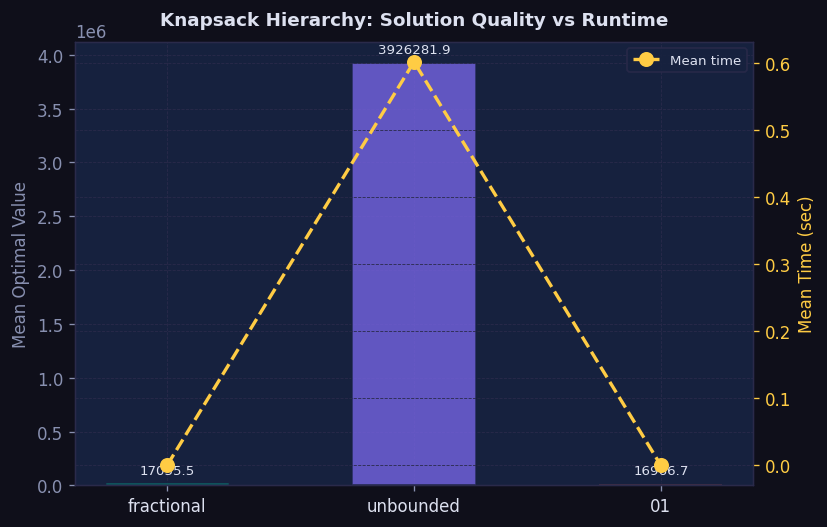

In [8]:
if "knapsack_type" not in df.columns:
    print("Column 'knapsack_type' not in CSV; skipping.")
else:
    ok = df[df["is_success"]].copy()
    types_needed = {"fractional", "unbounded", "01"}
    by_tid = ok.groupby("test_id")["knapsack_type"].apply(set)
    valid_tids = by_tid[by_tid.apply(lambda s: types_needed <= s)].index

    if len(valid_tids):
        aligned = ok[ok["test_id"].isin(valid_tids)]
        group_cols = ["test_id", "knapsack_type"]
    else:
        ok["_key"] = list(zip(ok["n"], ok["capacity"]))
        by_key = ok.groupby("_key")["knapsack_type"].apply(set)
        valid_keys = by_key[by_key.apply(lambda s: types_needed <= s)].index
        aligned = ok[ok["_key"].isin(valid_keys)]
        group_cols = ["_key", "knapsack_type"]

    if aligned.empty:
        print("No matched triples; skipping.")
    else:
        agg = (aligned.groupby(group_cols)
                      .agg(val=("optimal_value","max"), t=("time_sec","min"))
                      .reset_index())
        summary = (agg.groupby("knapsack_type")
                      .agg(mean_val=("val","mean"), mean_t=("t","mean"))
                      .reindex(["fractional","unbounded","01"]))

        TYPE_CLR = {"fractional":"#00d4aa","unbounded":"#7b68ee","01":"#ff6b6b"}
        x = np.arange(len(summary))
        fig, ax1 = plt.subplots(figsize=(7, 4.5), facecolor=FIG_BG)
        ax2 = ax1.twinx()
        ax2.set_facecolor(AX_BG)

        colors = [TYPE_CLR.get(t, PALETTE[0]) for t in summary.index]
        bars = ax1.bar(x, summary["mean_val"], color=colors, alpha=0.75,
                       edgecolor=AX_BG, width=0.5)
        ax2.plot(x, summary["mean_t"], "o--", color="#ffcc44",
                 lw=2, ms=8, label="Mean time")

        ax1.bar_label(bars, fmt="%.1f", padding=4, color=TEXT_CLR, fontsize=8)
        ax1.set_xticks(x)
        ax1.set_xticklabels(summary.index, color=TEXT_CLR)
        ax1.set_ylabel("Mean Optimal Value", color=MUTED_CLR)
        ax2.set_ylabel("Mean Time (sec)", color="#ffcc44")
        ax2.tick_params(colors="#ffcc44")
        ax2.legend(loc="upper right", fontsize=8)
        ax1.set_title("Knapsack Hierarchy: Solution Quality vs Runtime",
                      color=TEXT_CLR, pad=10, fontweight="bold")
        ax1.grid(color=GRID_CLR, linewidth=0.5, linestyle="--", axis="y")
        ax1.set_axisbelow(True)
        fig.tight_layout()
        save(fig, "knapsack_hierarchy.png")
        plt.show()